**BACKGROUND REMOVAL EXPERIMENTS**

In [2]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import seaborn as sns
import re
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from config import io_config


ENSEMBLE ALGORITHM

Processing images:   0%|          | 0/30 [00:00<?, ?it/s]

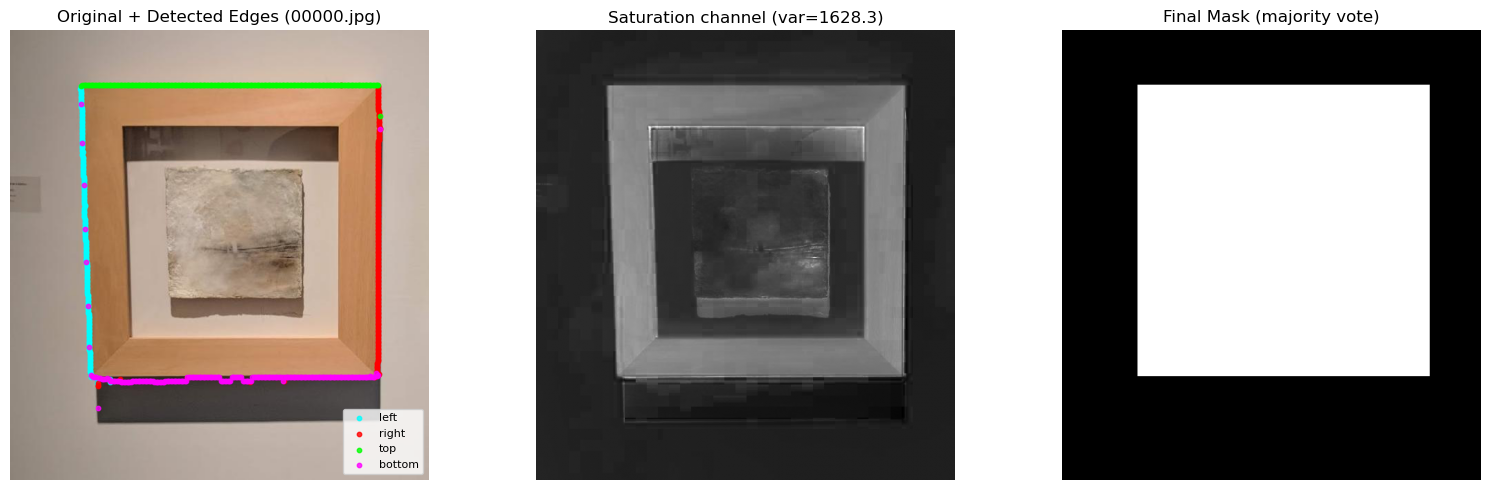

Processing images:   3%|▎         | 1/30 [00:18<08:46, 18.15s/it]

✅ Saved mask: 00000.png | Mode: saturation | Var(S)=1628.26


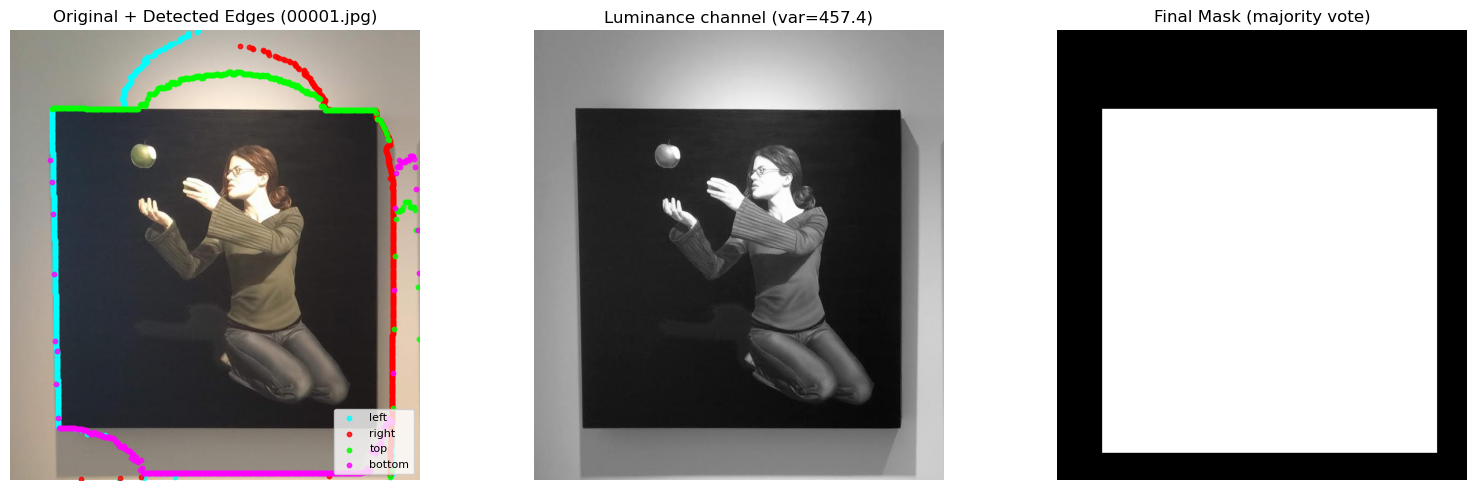

Processing images:   7%|▋         | 2/30 [00:33<07:48, 16.74s/it]

✅ Saved mask: 00001.png | Mode: luminance | Var(S)=457.43


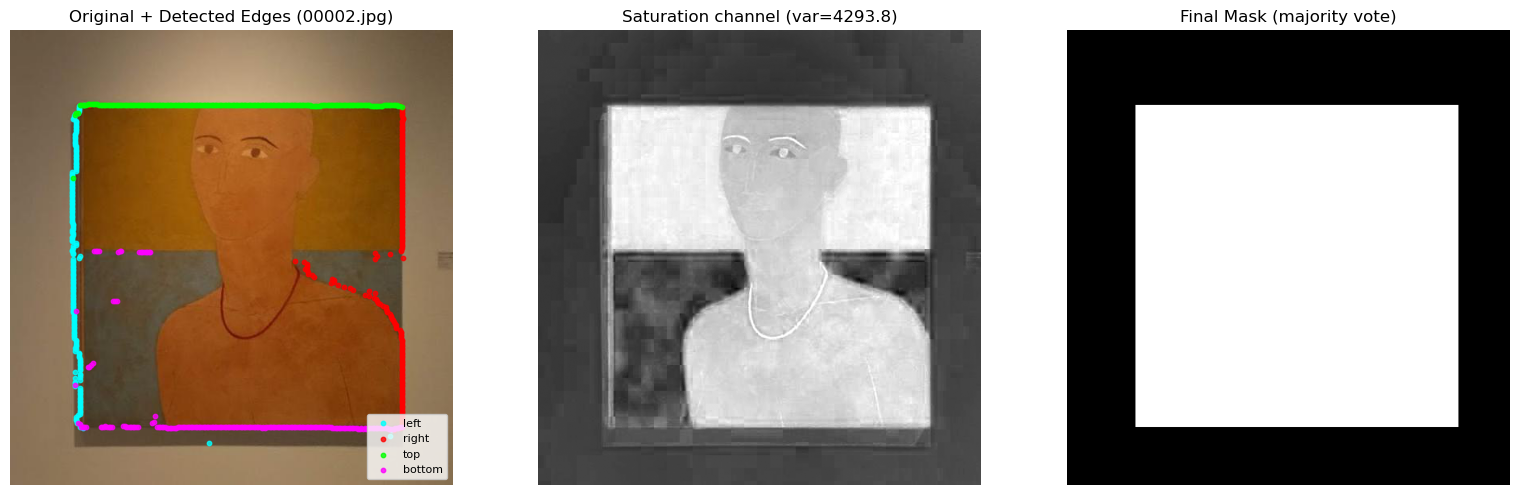

Processing images:  10%|█         | 3/30 [00:46<06:36, 14.70s/it]

✅ Saved mask: 00002.png | Mode: saturation | Var(S)=4293.83


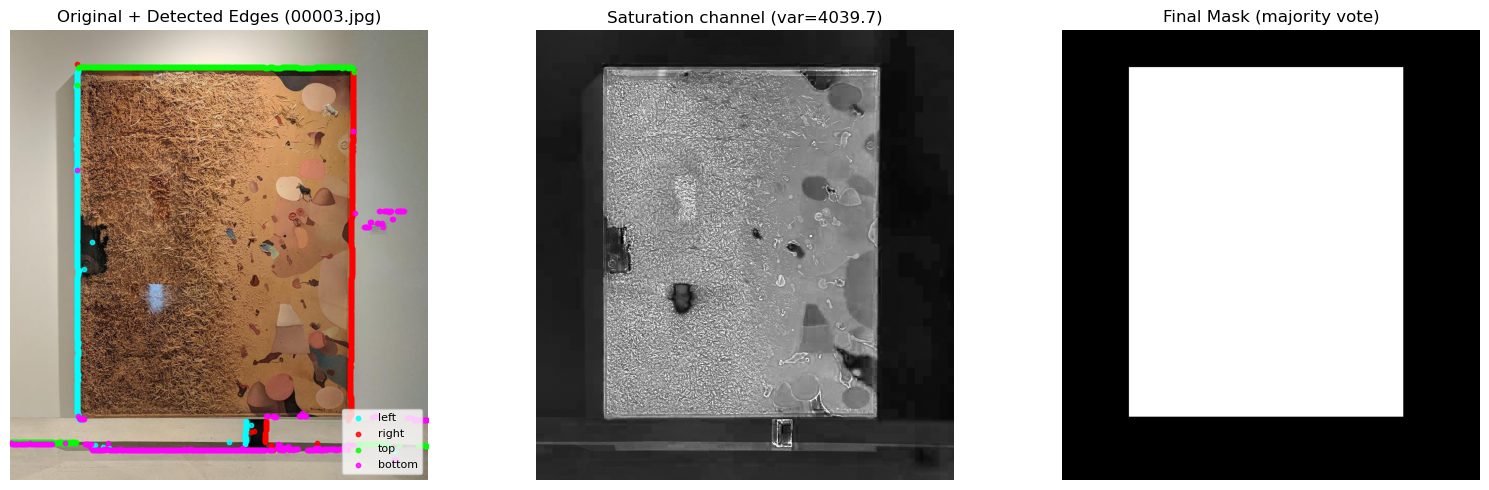

Processing images:  13%|█▎        | 4/30 [01:11<08:08, 18.77s/it]

✅ Saved mask: 00003.png | Mode: saturation | Var(S)=4039.74


Processing images:  13%|█▎        | 4/30 [01:19<08:38, 19.94s/it]


KeyboardInterrupt: 

In [ ]:

# FRAME EDGE DETECTION PIPELINE

import cv2
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from tqdm import tqdm
from pathlib import Path


# CONFIG
SCAN_STEP = 2
EDGE_BOOTSTRAPS = [10]
RUN_WINDOWS = [2]
DELTA_INTS = [35, 40, 45, 50, 55, 60, 65, 70]
CONSISTENCIES = [2]
TOLS = [15]
VAR_THRESHOLD = 480.0  # If var(S) < threshold → use luminance instead of saturation

MASK_DIR = Path("predicted_masks")
MASK_DIR.mkdir(exist_ok=True)


# BASE FUNCTIONS
def first_transition_idx(line, side="left", edge_bootstrap=10, run_window=7,
                         delta_int=20.0, consistency=7):
    """
    Detects the first consistent intensity transition along a 1D profile.
    """
    n = len(line)

    if side in ("left", "top"):
        base = np.mean(line[:edge_bootstrap])
        step_range = range(edge_bootstrap, n - run_window - consistency)
        direction = +1
    else:
        base = np.mean(line[-edge_bootstrap:])
        step_range = range(n - edge_bootstrap - run_window - consistency, edge_bootstrap, -1)
        direction = -1

    def win_mean(i): return np.mean(line[i:i + run_window])

    for i in step_range:
        seq = [win_mean(i + j * direction) for j in range(consistency)]
        if all(abs(m - base) > delta_int for m in seq):
            return i
    return None


def detect_edge_points(gray, direction="left", step=2, **params):
    """
    Scans image lines (horizontal/vertical) and collects edge points.
    """
    H, W = gray.shape
    pts = []

    if direction in ("left", "right"):
        for y in range(0, H, step):
            idx = first_transition_idx(gray[y, :], side=direction, **params)
            if idx is not None:
                pts.append((idx, y))
    else:
        for x in range(0, W, step):
            idx = first_transition_idx(gray[:, x], side=direction, **params)
            if idx is not None:
                pts.append((x, idx))

    return np.array(pts, dtype=float)


def filter_outliers(points, axis=0, tol=20):
    """
    Filters points beyond ±tol from median along chosen axis.
    """
    if points.size == 0:
        return points
    med = np.median(points[:, axis])
    return points[np.abs(points[:, axis] - med) < tol]


def get_adaptive_channel(img_rgb):
    """
    Chooses the most informative channel:
      - Saturation (S) by default
      - Luminance (Y) if S variance is too low
    """
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    ycbcr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)

    s = hsv[:, :, 1].astype(np.float32)
    Y = ycbcr[:, :, 0].astype(np.float32)

    var_s = np.var(s)
    if var_s < VAR_THRESHOLD:
        return Y.astype(np.uint8), "luminance", var_s
    else:
        return s.astype(np.uint8), "saturation", var_s


# IMAGE PROCESSING PIPELINE
def process_image(img_rgb, param_grid):
    """
    Performs edge detection and builds the final mask
    through majority voting.
    """
    gray, mode, var_s = get_adaptive_channel(img_rgb)
    H, W = gray.shape
    accum_mask = np.zeros((H, W), np.uint16)
    collected_edges = None

    for (edge_bootstrap, run_window, delta_int, consistency, tol) in param_grid:
        edges_raw = {
            "left": detect_edge_points(gray, "left", step=SCAN_STEP,
                                       edge_bootstrap=edge_bootstrap, run_window=run_window,
                                       delta_int=delta_int, consistency=consistency),
            "right": detect_edge_points(gray, "right", step=SCAN_STEP,
                                        edge_bootstrap=edge_bootstrap, run_window=run_window,
                                        delta_int=delta_int, consistency=consistency),
            "top": detect_edge_points(gray, "top", step=SCAN_STEP,
                                      edge_bootstrap=edge_bootstrap, run_window=run_window,
                                      delta_int=delta_int, consistency=consistency),
            "bottom": detect_edge_points(gray, "bottom", step=SCAN_STEP,
                                         edge_bootstrap=edge_bootstrap, run_window=run_window,
                                         delta_int=delta_int, consistency=consistency),
        }

        if collected_edges is None:
            collected_edges = edges_raw

        edges = {
            k: filter_outliers(v, axis=(0 if k in ["left", "right"] else 1), tol=tol)
            for k, v in edges_raw.items()
        }

        left_x = int(np.median(edges["left"][:, 0])) if edges["left"].size else 0
        right_x = int(np.median(edges["right"][:, 0])) if edges["right"].size else W - 1
        top_y = int(np.median(edges["top"][:, 1])) if edges["top"].size else 0
        bottom_y = int(np.median(edges["bottom"][:, 1])) if edges["bottom"].size else H - 1

        right_x, bottom_y = max(right_x, left_x + 1), max(bottom_y, top_y + 1)

        mask = np.zeros((H, W), np.uint8)
        mask[top_y:bottom_y, left_x:right_x] = 1
        accum_mask += mask

    threshold_votes = int(len(param_grid) * 0.5)
    final_mask = np.where(accum_mask >= threshold_votes, 255, 0).astype(np.uint8)

    return final_mask, gray, mode, var_s, collected_edges


# 🖼️ MAIN LOOP=
def run_background_removal(dev_dir, max_imgs=30):
    """
    Runs the frame detection pipeline across all .jpg images
    in a given directory and saves binary masks to `predicted_masks/`.
    """
    db_images = sorted([p for p in Path(dev_dir).iterdir() if p.suffix.lower() == ".jpg"])
    n_imgs = min(max_imgs, len(db_images))
    param_grid = list(product(EDGE_BOOTSTRAPS, RUN_WINDOWS, DELTA_INTS, CONSISTENCIES, TOLS))

    for img_path in tqdm(db_images[:n_imgs], desc="🧭 Processing images"):
        try:
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            final_mask, gray, mode, var_s, edges = process_image(img_rgb, param_grid)

            # Save mask
            mask_name = MASK_DIR / f"{img_path.stem}.png"
            cv2.imwrite(str(mask_name), final_mask)

            # Visualization
            fig, axs = plt.subplots(1, 3, figsize=(16, 5))
            plt.suptitle(f"{img_path.name} | Mode: {mode} | Var(S)={var_s:.1f}",
                         fontsize=11, fontweight="bold")

            # Original + Detected Edges
            axs[0].imshow(img_rgb)
            axs[0].set_title("Original + Detected Edges")
            axs[0].axis("off")

            if edges:
                color_map = {"left": "cyan", "right": "red", "top": "lime", "bottom": "magenta"}
                for k, c in color_map.items():
                    if edges[k].size:
                        axs[0].scatter(edges[k][:, 0], edges[k][:, 1], s=10, c=c, label=k, alpha=0.8)
                axs[0].legend(loc="lower right", fontsize=8)

            # Channel Used
            axs[1].imshow(gray, cmap="gray")
            axs[1].set_title(f"{mode.capitalize()} channel")
            axs[1].axis("off")

            # Final Mask
            axs[2].imshow(final_mask, cmap="gray")
            axs[2].set_title("Final Mask (Majority Vote)")
            axs[2].axis("off")

            plt.tight_layout()
            plt.show()

            print(f"✅ Saved mask: {mask_name.name}")

        except Exception as e:
            print(f"⚠️ Error processing {img_path.name}: {e}")


# RUN PIPELINE
run_background_removal(io_config.DEV_DIR)


In [58]:
import pickle
import cv2
import numpy as np
from pathlib import Path

data_dir = Path("../data/qsd2_w2")
gt_data = []

# Iterar sobre las imágenes PNG (tus máscaras)
for mask_path in sorted(data_dir.glob("*.png")):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is not None:
        gt_data.append([mask])  # lista anidada
    else:
        gt_data.append([])

# Guardar en formato .pkl compatible
with open(data_dir / "frames.pkl", "wb") as f:
    pickle.dump(gt_data, f)

print(f"✅ Guardado frames.pkl con {len(gt_data)} máscaras")


✅ Guardado frames.pkl con 30 máscaras


In [59]:
import pickle
import cv2
import numpy as np
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score

# ----------------------------
# Paths
# ----------------------------
GT_PATH = Path("../data/qsd2_w2/frames.pkl")       # Ground truth masks
PRED_MASKS_DIR = Path("predicted_masks")           # Predicted masks directory

# ----------------------------
# Load ground truth masks
# ----------------------------
with open(GT_PATH, "rb") as f:
    gt_data = pickle.load(f)

# Flatten structure (some entries are [[]], some [[mask]])
gt_masks = []
for i, entry in enumerate(gt_data):
    if isinstance(entry, list) and len(entry) > 0 and isinstance(entry[0], np.ndarray):
        gt_masks.append(entry[0])
    else:
        print(f"⚠️ GT frame {i} vacío o no válido.")
        gt_masks.append(None)

print(f"✅ Cargadas {len(gt_masks)} máscaras GT (algunas pueden ser None)")

# ----------------------------
# Load predicted masks
# ----------------------------
pred_paths = sorted(PRED_MASKS_DIR.glob("*.png"))
pred_masks = [cv2.imread(str(p), cv2.IMREAD_GRAYSCALE) for p in pred_paths]

print(f"✅ Cargadas {len(pred_masks)} máscaras predichas")

# ----------------------------
# Check alignment
# ----------------------------
n = min(len(gt_masks), len(pred_masks))
assert n > 0, "No hay máscaras para comparar."

# ----------------------------
# Compute metrics
# ----------------------------
precisions, recalls, f1s = [], [], []

for i in range(n):
    gt = gt_masks[i]
    pred = pred_masks[i]

    if gt is None:
        print(f"⚠️ Frame {i:02d} sin GT válida, se omite.")
        continue

    # Resize predicted mask if necessary
    if gt.shape != pred.shape:
        pred = cv2.resize(pred, (gt.shape[1], gt.shape[0]), interpolation=cv2.INTER_NEAREST)

    # Binarize (0 o 1)
    gt_bin = (gt > 127).astype(np.uint8).flatten()
    pred_bin = (pred > 127).astype(np.uint8).flatten()

    # Compute metrics
    prec = precision_score(gt_bin, pred_bin, zero_division=0)
    rec = recall_score(gt_bin, pred_bin, zero_division=0)
    f1 = f1_score(gt_bin, pred_bin, zero_division=0)

    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    print(f"[{i:02d}] Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")

# ----------------------------
# Global metrics
# ----------------------------
if precisions:
    print("\n=== 📊 Resultados globales ===")
    print(f"Media Precision: {np.mean(precisions):.3f}")
    print(f"Media Recall:    {np.mean(recalls):.3f}")
    print(f"Media F1-score:  {np.mean(f1s):.3f}")
else:
    print("⚠️ No se pudieron calcular métricas (todas las GT estaban vacías).")


✅ Cargadas 30 máscaras GT (algunas pueden ser None)
✅ Cargadas 30 máscaras predichas
[00] Precision=0.994  Recall=0.991  F1=0.992
[01] Precision=0.893  Recall=0.997  F1=0.942
[02] Precision=0.995  Recall=0.982  F1=0.989
[03] Precision=0.994  Recall=0.984  F1=0.989
[04] Precision=0.983  Recall=0.984  F1=0.984
[05] Precision=0.993  Recall=0.989  F1=0.991
[06] Precision=0.998  Recall=0.992  F1=0.995
[07] Precision=0.990  Recall=0.999  F1=0.995
[08] Precision=1.000  Recall=0.990  F1=0.995
[09] Precision=0.934  Recall=0.995  F1=0.964
[10] Precision=0.995  Recall=0.985  F1=0.990
[11] Precision=0.996  Recall=0.986  F1=0.991
[12] Precision=0.994  Recall=0.989  F1=0.991
[13] Precision=0.969  Recall=0.984  F1=0.976
[14] Precision=1.000  Recall=0.922  F1=0.960
[15] Precision=1.000  Recall=0.959  F1=0.979
[16] Precision=0.997  Recall=0.989  F1=0.993
[17] Precision=0.999  Recall=0.970  F1=0.984
[18] Precision=0.996  Recall=0.988  F1=0.992
[19] Precision=0.987  Recall=0.984  F1=0.985
[20] Precision=